# SENG 5360 — Intelligent Control
## Session 1: Lab 1 — The model and the simulator

**Dr. Gerardo Flores — Texas A&M International University**

This notebook combines Codes **1.1** and **1.2** so that the model, controllers, simulation, and plot can be executed in order.

### Google Colab
Open the notebook in Colab and select **Runtime → Run all**. NumPy, SciPy, and Matplotlib are normally preinstalled.

## Code 1.1 — Lab 1: the model and the simulator

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

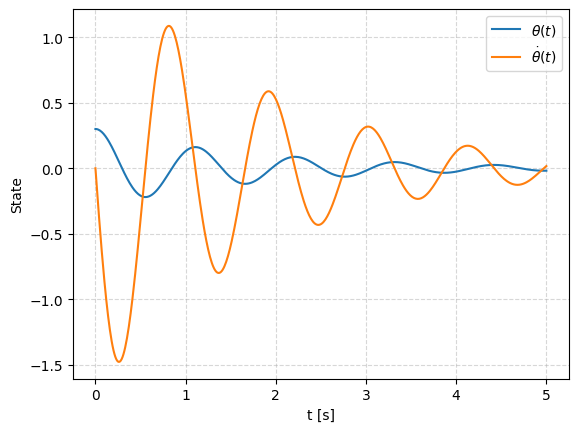

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Pendulum parameters
m, l, b, g = 0.5, 0.3, 0.05, 9.81

# Nonlinear model: x_dot = f(t, x, u)
def f(t, x, u):
    # State: x = [theta, theta_dot]
    th, om = x

    dth = om
    dom = (
        -(g/l) * np.sin(th)
        -(b/(m*l**2)) * om
        + u/(m*l**2)
    )

    return [dth, dom]

# Open-loop input
def u_zero(t, x):
    return 0.0

# Simulation settings
x0 = [0.3, 0.0]                  # Initial angle and angular velocity
t_eval = np.linspace(0, 5, 501)

# Simulate x_dot = f(t, x, u)
sol = solve_ivp(
    lambda t, x: f(t, x, u_zero(t, x)),
    [0, 5],
    x0,
    t_eval=t_eval
)

# Plot the states
plt.plot(sol.t, sol.y[0], label=r"$\theta(t)$")
plt.plot(sol.t, sol.y[1], label=r"$\dot{\theta}(t)$")
plt.xlabel("t [s]")
plt.ylabel("State")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

## Code 1.2 — Lab 1: what to do

Choose a controller by assigning the corresponding **function** to `ctrl`. Change the gains or initial condition and rerun the simulation.

In [ ]:
def u_zero(t, x):
    return 0.0

def u_pd(t, x, kp=5.0, kd=1.0):
    return -kp*x[0] - kd*x[1]

ctrl = u_zero   # A FUNCTION; swap for u_pd

# Other gains:
# ctrl = lambda t, x: u_pd(t, x, kp=1.0, kd=1.0)

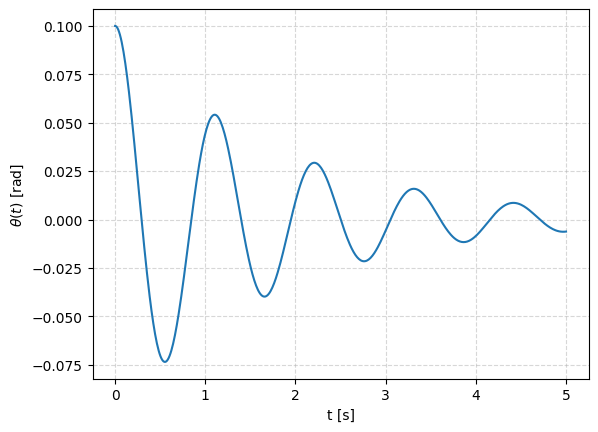

In [ ]:
sol = solve_ivp(
    lambda t, x: f(t, x, ctrl(t, x)),
    [0, 5],
    [0.1, 0.0],
    max_step=0.01
)

plt.plot(sol.t, sol.y[0])
plt.xlabel("t [s]")
plt.ylabel(r"$\theta(t)$ [rad]")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()